In [ ]:
from google.colab import files
uploaded = files.upload()
# Upload archive__5_.zip

Saving archive (5).zip to archive (5) (1).zip


In [ ]:
import zipfile
import pandas as pd

# Extract zip
with zipfile.ZipFile('archive (5).zip', 'r') as zip_ref:
    zip_ref.extractall('.')

# Load dataset
ifood_df = pd.read_csv('ifood_df.csv')
print("Shape:", ifood_df.shape)
print(ifood_df.head())

Shape: (2205, 39)
    Income  Kidhome  Teenhome  Recency  MntWines  MntFruits  MntMeatProducts  \
0  58138.0        0         0       58       635         88              546   
1  46344.0        1         1       38        11          1                6   
2  71613.0        0         0       26       426         49              127   
3  26646.0        1         0       26        11          4               20   
4  58293.0        1         0       94       173         43              118   

   MntFishProducts  MntSweetProducts  MntGoldProds  ...  marital_Together  \
0              172                88            88  ...                 0   
1                2                 1             6  ...                 0   
2              111                21            42  ...                 1   
3               10                 3             5  ...                 1   
4               46                27            15  ...                 0   

   marital_Widow  education_2n Cycle  

In [ ]:
print(ifood_df.describe().T)

                       count          mean           std     min      25%  \
Income                2205.0  51622.094785  20713.063826  1730.0  35196.0   
Kidhome               2205.0      0.442177      0.537132     0.0      0.0   
Teenhome              2205.0      0.506576      0.544380     0.0      0.0   
Recency               2205.0     49.009070     28.932111     0.0     24.0   
MntWines              2205.0    306.164626    337.493839     0.0     24.0   
MntFruits             2205.0     26.403175     39.784484     0.0      2.0   
MntMeatProducts       2205.0    165.312018    217.784507     0.0     16.0   
MntFishProducts       2205.0     37.756463     54.824635     0.0      3.0   
MntSweetProducts      2205.0     27.128345     41.130468     0.0      1.0   
MntGoldProds          2205.0     44.057143     51.736211     0.0      9.0   
NumDealsPurchases     2205.0      2.318367      1.886107     0.0      1.0   
NumWebPurchases       2205.0      4.100680      2.737424     0.0      2.0   

In [ ]:
ifood_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2205 entries, 0 to 2204
Data columns (total 39 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Income                2205 non-null   float64
 1   Kidhome               2205 non-null   int64  
 2   Teenhome              2205 non-null   int64  
 3   Recency               2205 non-null   int64  
 4   MntWines              2205 non-null   int64  
 5   MntFruits             2205 non-null   int64  
 6   MntMeatProducts       2205 non-null   int64  
 7   MntFishProducts       2205 non-null   int64  
 8   MntSweetProducts      2205 non-null   int64  
 9   MntGoldProds          2205 non-null   int64  
 10  NumDealsPurchases     2205 non-null   int64  
 11  NumWebPurchases       2205 non-null   int64  
 12  NumCatalogPurchases   2205 non-null   int64  
 13  NumStorePurchases     2205 non-null   int64  
 14  NumWebVisitsMonth     2205 non-null   int64  
 15  AcceptedCmp3         

In [ ]:
print(ifood_df.isna().sum())
print("\nDuplicate rows:", ifood_df.duplicated().sum())

Income                  0
Kidhome                 0
Teenhome                0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
AcceptedCmp3            0
AcceptedCmp4            0
AcceptedCmp5            0
AcceptedCmp1            0
AcceptedCmp2            0
Complain                0
Z_CostContact           0
Z_Revenue               0
Response                0
Age                     0
Customer_Days           0
marital_Divorced        0
marital_Married         0
marital_Single          0
marital_Together        0
marital_Widow           0
education_2n Cycle      0
education_Basic         0
education_Graduation    0
education_Master        0
education_PhD           0
MntTotal                0
MntRegularProds         0
AcceptedCmpO

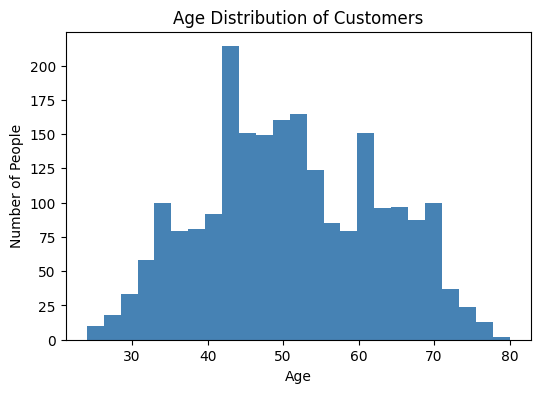

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.hist(ifood_df["Age"], bins=25, color='steelblue')
plt.title("Age Distribution of Customers")
plt.xlabel("Age")
plt.ylabel("Number of People")
plt.show()

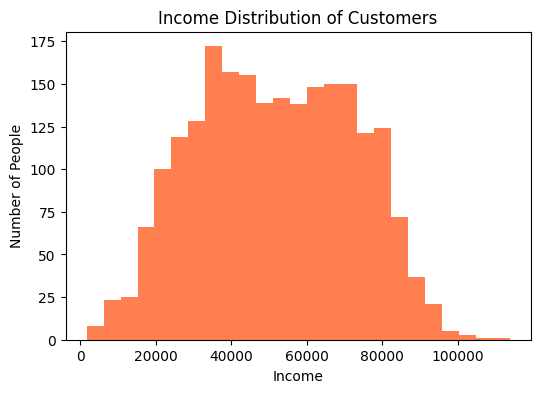

In [ ]:
plt.figure(figsize=(6,4))
plt.hist(ifood_df["Income"], bins=25, color='coral')
plt.title("Income Distribution of Customers")
plt.xlabel("Income")
plt.ylabel("Number of People")
plt.show()

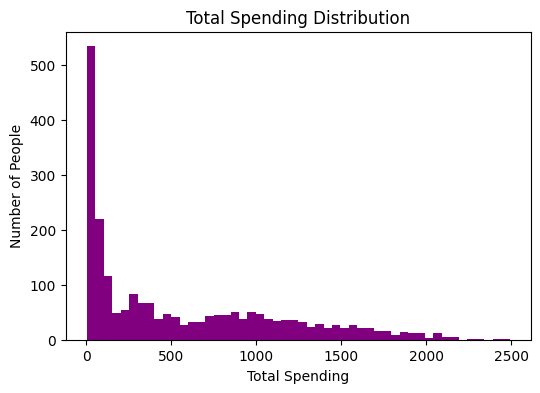

In [ ]:
plt.figure(figsize=(6,4))
plt.hist(ifood_df["MntTotal"], bins=50, color='purple')
plt.title("Total Spending Distribution")
plt.xlabel("Total Spending")
plt.ylabel("Number of People")
plt.show()

High value threshold (80th percentile): 1098.2


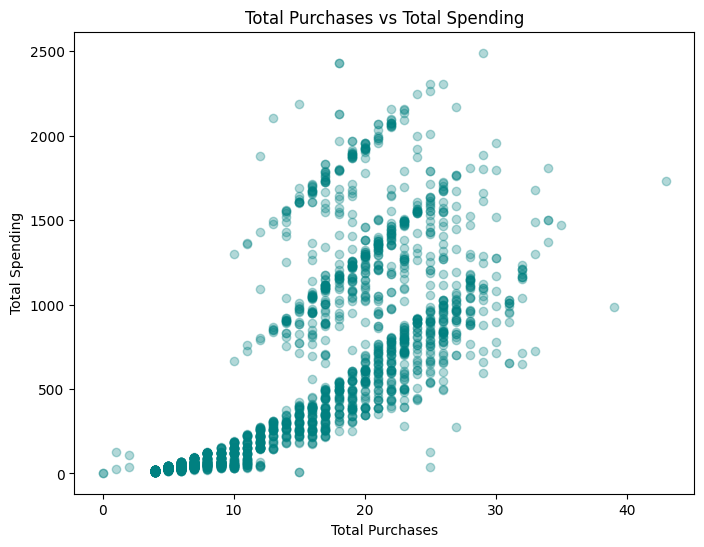

In [ ]:
channel_columns = ["NumDealsPurchases", "NumWebPurchases",
                   "NumCatalogPurchases", "NumStorePurchases"]

high_value_threshold = ifood_df["MntTotal"].quantile(0.80)
print("High value threshold (80th percentile):", high_value_threshold)

ifood_df["TotalPurchases"] = ifood_df[channel_columns].sum(axis=1)

plt.figure(figsize=(8,6))
plt.scatter(ifood_df["TotalPurchases"], ifood_df["MntTotal"],
            alpha=0.3, color='teal')
plt.title("Total Purchases vs Total Spending")
plt.xlabel("Total Purchases")
plt.ylabel("Total Spending")
plt.show()

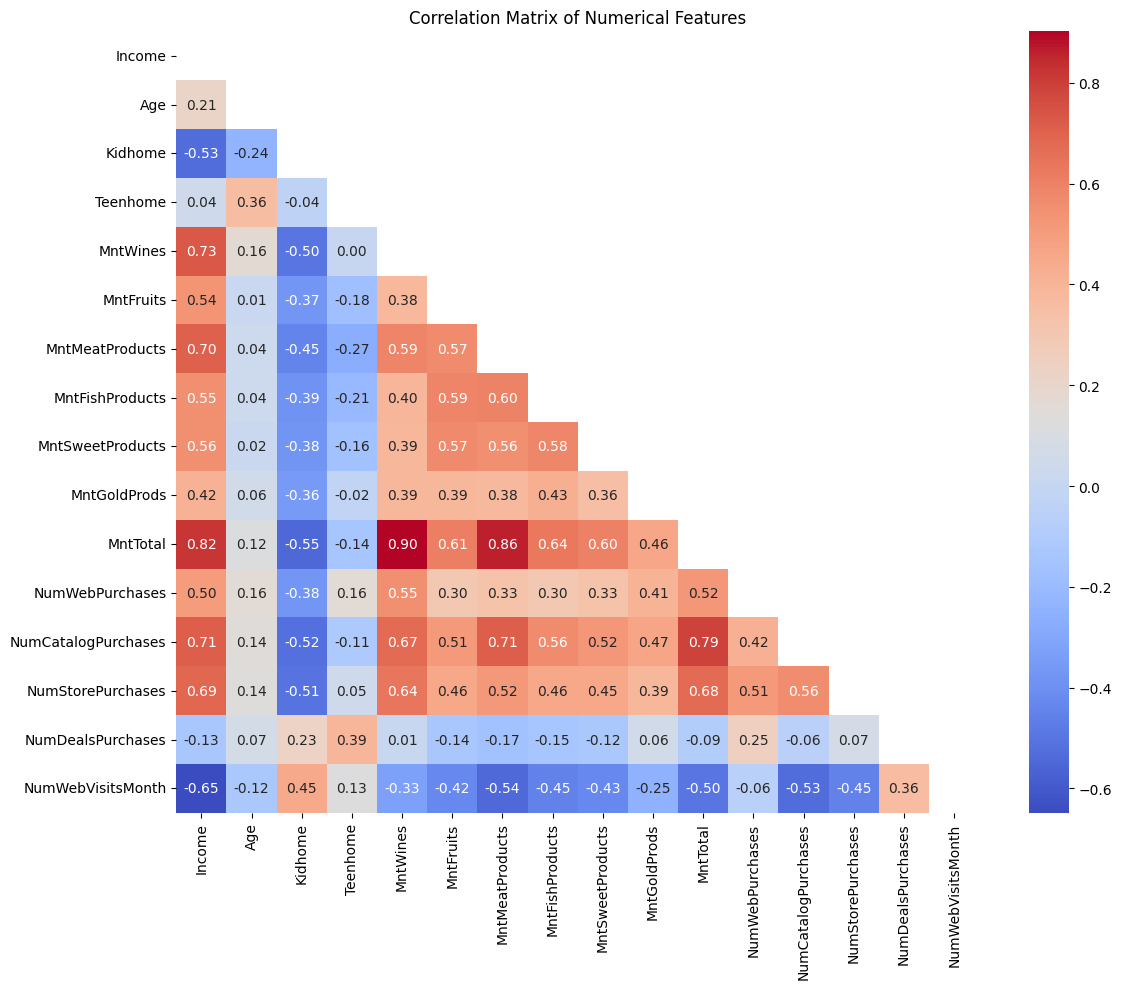

In [ ]:
import seaborn as sns
import numpy as np

numerical_columns = [
    'Income', 'Age', 'Kidhome', 'Teenhome',
    'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts',
    'MntSweetProducts', 'MntGoldProds', 'MntTotal', 'NumWebPurchases',
    'NumCatalogPurchases', 'NumStorePurchases', 'NumDealsPurchases',
    'NumWebVisitsMonth'
]

correlation_matrix = ifood_df[numerical_columns].corr()
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))

plt.figure(figsize=(12,10))
sns.heatmap(correlation_matrix, mask=mask, annot=True,
            fmt='.2f', cmap='coolwarm', cbar=True)
plt.title('Correlation Matrix of Numerical Features')
plt.tight_layout()
plt.show()

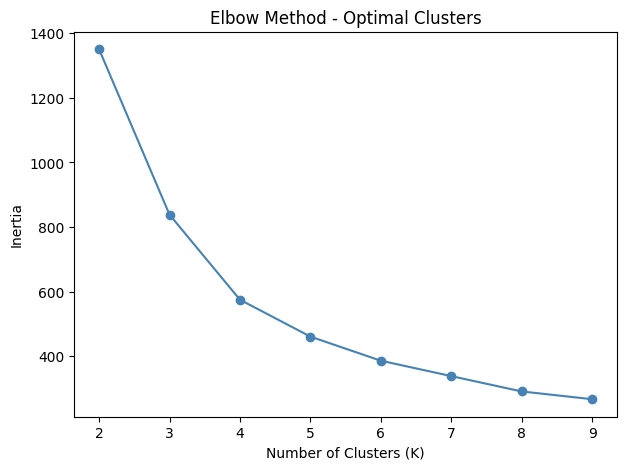

In [ ]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
cols_for_clustering = ['Income', 'MntTotal']
data_scaled = ifood_df[cols_for_clustering].dropna()
data_scaled_values = scaler.fit_transform(data_scaled)

inertia_list = []
for K in range(2,10):
    inertia = KMeans(n_clusters=K, random_state=7).fit(data_scaled_values).inertia_
    inertia_list.append(inertia)

plt.figure(figsize=(7,5))
plt.plot(range(2,10), inertia_list, color='steelblue', marker='o')
plt.title("Elbow Method - Optimal Clusters")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.show()

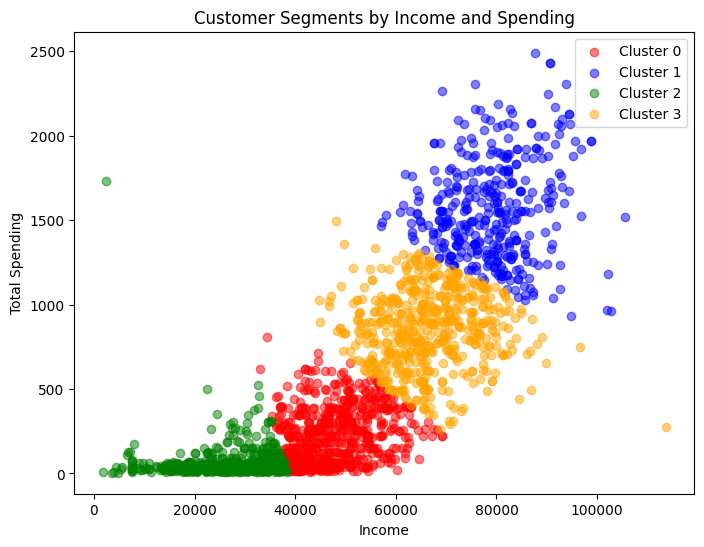

               Income     MntTotal
Cluster                           
0        47611.477165   225.407874
1        79106.693767  1563.501355
2        26649.474016    61.351181
3        66220.220848   851.363958


In [ ]:
model = KMeans(n_clusters=4, random_state=7)
ifood_df['Cluster'] = model.fit_predict(data_scaled_values)

plt.figure(figsize=(8,6))
colors = ['red', 'blue', 'green', 'orange']
for i in range(4):
    cluster_data = ifood_df[ifood_df['Cluster']==i]
    plt.scatter(cluster_data['Income'], cluster_data['MntTotal'],
                alpha=0.5, label=f'Cluster {i}', color=colors[i])
plt.title('Customer Segments by Income and Spending')
plt.xlabel('Income')
plt.ylabel('Total Spending')
plt.legend()
plt.show()

print(ifood_df.groupby('Cluster')[['Income','MntTotal']].mean())

In [ ]:
print("=== CUSTOMER SEGMENTATION RECOMMENDATIONS ===\n")

cluster_summary = ifood_df.groupby('Cluster')[['Income','MntTotal']].mean()
for i in range(4):
    inc = round(cluster_summary.loc[i,'Income'])
    mnt = round(cluster_summary.loc[i,'MntTotal'])
    print(f"Cluster {i}: Avg Income = {inc}, Avg Spending = {mnt}")

print("\n1. High income high spenders → Target with premium products")
print("2. Low income low spenders → Offer discounts and deals")
print("3. High income low spenders → Re-engage with targeted campaigns")
print("4. Low income high spenders → Loyalty rewards program")
print("\nThese insights help businesses make smarter marketing decisions! ✅")

=== CUSTOMER SEGMENTATION RECOMMENDATIONS ===

Cluster 0: Avg Income = 47611, Avg Spending = 225
Cluster 1: Avg Income = 79107, Avg Spending = 1564
Cluster 2: Avg Income = 26649, Avg Spending = 61
Cluster 3: Avg Income = 66220, Avg Spending = 851

1. High income high spenders → Target with premium products
2. Low income low spenders → Offer discounts and deals
3. High income low spenders → Re-engage with targeted campaigns
4. Low income high spenders → Loyalty rewards program

These insights help businesses make smarter marketing decisions! ✅
